In [50]:
# import libraries
import pandas as pd
import numpy as np
from retrieve.get_data import get_yield
from statsmodels.tsa.api import VAR

In [51]:
# weekly realised volatility = sqrt(sum of squared daily yield changes)
# log-transformed for stationarity — following DY 2008 log-vol specification
term = 5
raw_d = get_yield(term=term, freq='B')
chg_d = raw_d.diff().dropna()

rvol_w = (chg_d ** 2).resample('W-FRI').sum().apply(np.sqrt)
rvol_w = rvol_w.dropna()

# log-transform: ln(rvol) — handles positive skew, compresses outliers
df = np.log(rvol_w.replace(0, np.nan)).dropna()

df

,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO
2012-01-27,-2.222334,-2.526803,-2.768668,-2.278142,-1.806534,-2.802421,-3.772261,-4.017384,-5.756463,-1.730474,-2.366502
2012-02-03,-2.604879,-2.362428,-2.041673,-2.318124,-2.172828,-2.069525,-2.671448,-4.735853,-2.958735,-2.125289,-2.620024
2012-02-10,-2.632055,-2.038016,-2.959107,-1.989482,-1.542030,-1.702256,-2.826497,-3.990350,-2.866245,-1.782447,-2.389762
2012-02-17,-2.569121,-2.670305,-2.558081,-2.667906,-1.924688,-3.231855,-4.415952,-3.615360,-3.300135,-2.040221,-2.690849
2012-02-24,-2.614862,-2.304831,-2.610308,-2.574260,-2.229454,-1.256073,-3.562334,-4.195280,-2.440594,-1.418374,-3.912023
...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,-2.142232,-3.193309,-3.118938,-3.225799,-2.343299,-2.989175,-2.180289,-2.682229,-3.275740,-2.512316,-2.371757
2026-02-20,-3.314305,-3.665865,-3.940308,-4.360880,-2.254975,-2.272791,-3.114861,-2.755384,-3.472729,-2.324770,-2.913314
2026-02-27,-2.198469,-2.715828,-2.899431,-2.714669,-2.678928,-3.733186,-2.770322,-3.329667,-3.616051,-2.341998,-2.449636
2026-03-06,-2.056427,-1.366082,-1.632277,-1.829311,-1.736707,-1.998491,-2.439935,-2.354377,-2.222632,-0.911229,-1.448505


In [52]:
# Augmented Dickey-Fuller test on ln(rvol) levels
# Expect stationarity — vol mean-reverts unlike yield levels
from statsmodels.tsa.stattools import adfuller

adf_results = []
for col in df.columns:
    series = df[col].dropna()
    result = adfuller(series, autolag=None)
    stat, pval = result[0], result[1]
    adf_results.append({
        "Country": col,
        "ADF Statistic": round(stat, 4),
        "p-value": round(pval, 4),
        "Stationary (5%)": "Yes" if pval < 0.05 else "No",
    })

pd.DataFrame(adf_results).set_index("Country")

,ADF Statistic,p-value,Stationary (5%)
Country,,,
US,-2.5078,0.1136,No
UK,-1.9321,0.3171,No
FRA,-2.2915,0.1747,No
GER,-1.8281,0.3666,No
AUS,-2.4627,0.1248,No
INDO,-4.8466,0.0000,Yes
INDIA,-3.1452,0.0234,Yes
JAPAN,-2.6521,0.0827,No
SWITZ,-2.4227,0.1354,No


In [53]:
# VAR lag selection
model = VAR(df)
order = model.select_order(maxlags=7)
print(order.summary())

p = order.selected_orders["aic"]
results = model.fit(p)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -13.79      -13.72   1.025e-06      -13.76
1      -15.98     -15.14*   1.149e-07     -15.66*
2      -16.27      -14.66   8.612e-08      -15.65
3     -16.35*      -13.98  7.923e-08*      -15.44
4      -16.29      -13.16   8.405e-08      -15.08
5      -16.20      -12.30   9.203e-08      -14.70
6      -16.16      -11.49   9.601e-08      -14.36
7      -16.07      -10.63   1.064e-07      -13.97
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 11, Apr, 2026
Time:                     13:30:30
--------------------------------------------------------------------
No. of Equations:         11.0000    BIC:                   -13.9846
Nobs:                     727.000    HQIC:                  -15.4344
Log likelihood:   

/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [54]:
# Granger causality — all pairwise combinations
for caused in results.names:
    for causing in results.names:
        if caused != causing:
            test = results.test_causality(caused, [causing], kind='f')
            pval = test.pvalue
            sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            print(f"{causing} -> {caused}: p-value = {pval:.4f} {sig}")

UK -> US: p-value = 0.4906 
FRA -> US: p-value = 0.3349 
GER -> US: p-value = 0.0109 **
AUS -> US: p-value = 0.0016 ***
INDO -> US: p-value = 0.1829 
INDIA -> US: p-value = 0.0132 **
JAPAN -> US: p-value = 0.3854 
SWITZ -> US: p-value = 0.5120 
BRAZIL -> US: p-value = 0.6417 
MEXICO -> US: p-value = 0.0001 ***
US -> UK: p-value = 0.7480 
FRA -> UK: p-value = 0.2791 
GER -> UK: p-value = 0.3741 
AUS -> UK: p-value = 0.0001 ***
INDO -> UK: p-value = 0.6502 
INDIA -> UK: p-value = 0.3901 
JAPAN -> UK: p-value = 0.4027 
SWITZ -> UK: p-value = 0.6836 
BRAZIL -> UK: p-value = 0.4739 
MEXICO -> UK: p-value = 0.0000 ***
US -> FRA: p-value = 0.7682 
UK -> FRA: p-value = 0.9249 
GER -> FRA: p-value = 0.3649 
AUS -> FRA: p-value = 0.0030 ***
INDO -> FRA: p-value = 0.6895 
INDIA -> FRA: p-value = 0.4842 
JAPAN -> FRA: p-value = 0.9561 
SWITZ -> FRA: p-value = 0.7689 
BRAZIL -> FRA: p-value = 0.0413 **
MEXICO -> FRA: p-value = 0.0005 ***
US -> GER: p-value = 0.4415 
UK -> GER: p-value = 0.6722 
FRA

In [55]:
# Cholesky FEVD (for comparison — ordering dependent)
fevd = results.fevd(10)
fevd.summary()

FEVD for US
           US        UK       FRA       GER       AUS      INDO     INDIA     JAPAN     SWITZ    BRAZIL    MEXICO
0    1.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1    0.962082  0.001373  0.001922  0.001643  0.017120  0.003344  0.003286  0.002384  0.001103  0.000120  0.005622
2    0.924020  0.002253  0.001892  0.004362  0.022267  0.003337  0.011636  0.004850  0.001852  0.002287  0.021245
3    0.899631  0.008388  0.002130  0.010323  0.026189  0.003803  0.010656  0.008083  0.003516  0.002241  0.025041
4    0.880321  0.011958  0.003071  0.010672  0.032040  0.003713  0.010949  0.008892  0.004674  0.002140  0.031571
5    0.864843  0.013322  0.003399  0.011085  0.035842  0.003967  0.012196  0.009704  0.005395  0.002072  0.038174
6    0.853101  0.014952  0.003600  0.011762  0.038853  0.003979  0.012345  0.010923  0.005820  0.002011  0.042654
7    0.842635  0.016275  0.003908  0.011849  0.041381  0.004214  0.012743  0

In [56]:
def generalized_fevd(var_results, H=10, normalize=True):
    
    names = list(var_results.names)
    n = len(names)

    Psi = var_results.ma_rep(H)
    Sigma = np.asarray(var_results.sigma_u)
    sigma_diag = np.diag(Sigma).copy()

    fevd = np.zeros((H, n, n), dtype=float)

    cum_numer = np.zeros((n, n), dtype=float)
    cum_denom = np.zeros(n, dtype=float)

    for h in range(H):
        A = Psi[h] @ Sigma
        cum_denom += np.diag(A @ Psi[h].T)
        cum_numer += (A ** 2)

        fevd[h] = (cum_numer / sigma_diag) / cum_denom[:, None]

        if normalize:
            row_sums = fevd[h].sum(axis=1, keepdims=True)
            fevd[h] = fevd[h] / row_sums

    return fevd, names


def fevd_table(fevd, names, country, horizons=None):    
    
    idx = names.index(country)
    H = fevd.shape[0]
    
    if horizons is None:
        horizons = range(H)

    rows = [fevd[h, idx, :] for h in horizons]
    out = pd.DataFrame(rows, columns=names, index=list(horizons))
    out.index.name = "horizon"
    
    return out


def spillover_table(fevd, names, H_index=-1):
    theta = fevd[H_index]
    n = theta.shape[0]

    table = pd.DataFrame(theta * 100, index=names, columns=names)

    table["FROM_others"] = table.sum(axis=1) - np.diag(theta) * 100

    to_others = table[names].sum(axis=0) - np.diag(theta) * 100
    table.loc["TO_others"] = list(to_others) + [np.nan]

    net = to_others.values - table.loc[table.index.isin(names), "FROM_others"].values
    table.loc["NET"] = list(net) + [np.nan]

    total = (theta.sum() - np.trace(theta)) / n * 100

    return table, total


In [57]:
# generalized FEVD - individual country decompositions
gfevd, names = generalized_fevd(results, H=10, normalize=True)

# e.g., how much of UK volatility forecast error comes from each country
fevd_table(gfevd, names, "UK")

,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO
horizon,,,,,,,,,,,
0,0.092889,0.539056,0.091106,0.135308,0.051555,0.006550,0.002455,0.007504,0.062595,0.007313,0.003669
1,0.095751,0.505728,0.095246,0.135964,0.065584,0.008957,0.004548,0.007229,0.064192,0.006901,0.009901
2,0.096208,0.490673,0.097671,0.135676,0.072839,0.008615,0.004981,0.007539,0.063499,0.006884,0.015415
3,0.098278,0.470377,0.098336,0.131142,0.079845,0.008128,0.005187,0.008166,0.064930,0.007262,0.028349
4,0.099484,0.455709,0.099266,0.129963,0.085341,0.007837,0.005295,0.008617,0.065382,0.007350,0.035755
5,0.100794,0.444239,0.099891,0.129244,0.089651,0.007606,0.005110,0.009011,0.065101,0.007269,0.042085
6,0.102181,0.435359,0.099818,0.128154,0.092513,0.007428,0.004968,0.009508,0.065104,0.007249,0.047719
7,0.103117,0.427956,0.099927,0.127444,0.094865,0.007299,0.004847,0.009900,0.065066,0.007221,0.052359
8,0.104057,0.421606,0.100003,0.126913,0.096716,0.007239,0.004753,0.010268,0.064988,0.007151,0.056307


In [58]:
# Diebold-Yilmaz volatility spillover table
table, total = spillover_table(gfevd, names)
print(f"Total volatility spillover index: {total:.1f}%")
table

Total volatility spillover index: 43.3%


,US,UK,FRA,GER,AUS,INDO,INDIA,JAPAN,SWITZ,BRAZIL,MEXICO,FROM_others
US,43.484014,10.410470,6.138823,7.045816,10.025061,1.455619,1.112159,4.528152,6.478038,1.228724,8.093124,56.515986
UK,10.485467,41.644805,10.005740,12.645619,9.809595,0.721390,0.469184,1.060497,6.493825,0.710411,5.953469,58.355195
FRA,5.254168,8.923704,37.348823,25.385316,5.767056,0.509184,0.208438,2.362221,7.530360,1.634271,5.076458,62.651177
GER,5.777298,10.623195,24.906376,35.820670,4.817608,0.259214,0.251954,2.497939,8.946958,0.883977,5.214810,64.179330
AUS,7.639949,10.719149,6.380383,6.543431,57.905445,1.061184,0.859803,2.098113,3.207830,0.800488,2.784225,42.094555
INDO,3.128467,2.470126,0.984912,0.664828,1.461197,81.923952,3.866848,0.571686,1.731685,1.605722,1.590575,18.076048
INDIA,3.054071,0.487431,1.094251,1.110382,1.651341,4.847221,81.192781,0.171230,1.319177,1.407366,3.664748,18.807219
JAPAN,5.645494,1.400838,3.729082,3.679638,3.145674,0.430049,1.936905,73.513150,2.015493,0.488343,4.015334,26.486850
SWITZ,9.257630,7.961702,11.486791,12.875381,4.118281,0.633652,0.640347,1.738935,42.714954,0.818699,7.753628,57.285046
BRAZIL,3.162526,2.006906,4.532644,2.451352,1.715925,4.996746,0.786763,0.163593,3.297718,72.188833,4.696994,27.811167


/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency informatio

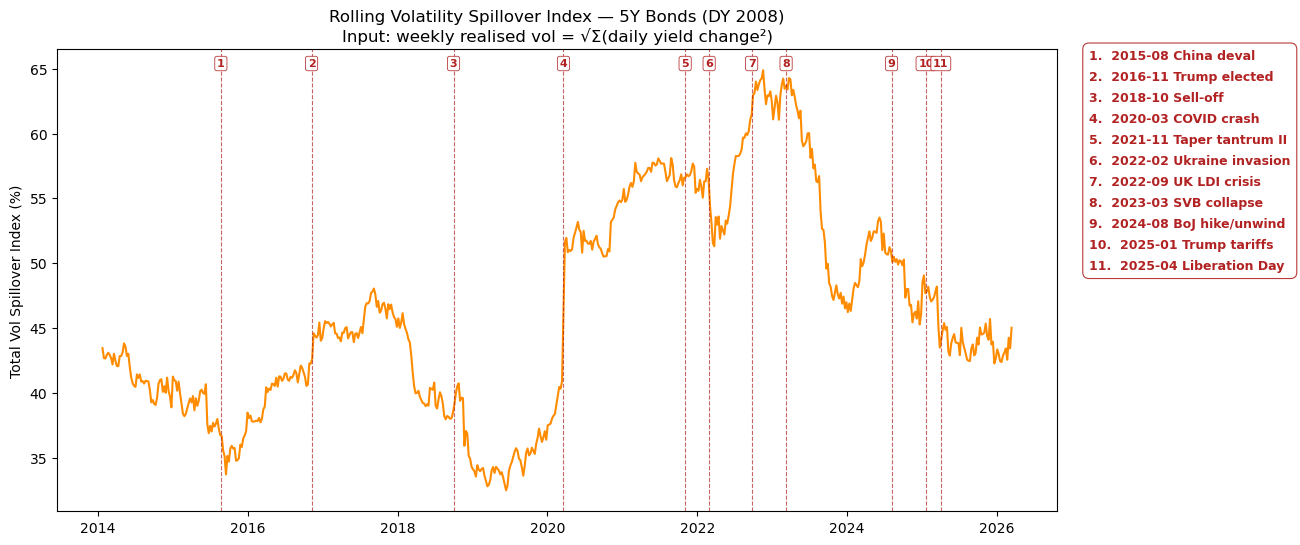

count    626.000000
mean      46.269056
std        8.085015
min       32.471288
25%       40.059559
50%       44.654456
75%       52.311611
max       64.883961
Name: Total Vol Spillover Index (%), dtype: float64

In [59]:
# ── ROLLING TOTAL VOLATILITY SPILLOVER INDEX (Diebold-Yilmaz 2008) ─────────────
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

ROLL_WINDOW = 104   # 2-year rolling window
VAR_LAGS    = 1
FEVD_H      = 10

dates = df.index
spillover_ts = {}

for i in range(ROLL_WINDOW, len(dates)):
    window = df.iloc[i - ROLL_WINDOW : i]
    window = window.replace([np.inf, -np.inf], np.nan).dropna()
    if len(window) < ROLL_WINDOW * 0.8:
        continue
    try:
        res = VAR(window).fit(VAR_LAGS)
        gfevd_w, names_w = generalized_fevd(res, H=FEVD_H, normalize=True)
        _, total_w = spillover_table(gfevd_w, names_w)
        spillover_ts[dates[i]] = total_w
    except Exception:
        continue

spill = pd.Series(spillover_ts, name="Total Vol Spillover Index (%)")

events = {
    "2015-08 China deval":       "2015-08-24",
    "2016-11 Trump elected":     "2016-11-08",
    "2018-10 Sell-off":          "2018-10-01",
    "2020-03 COVID crash":       "2020-03-20",
    "2021-11 Taper tantrum II":  "2021-11-03",
    "2022-02 Ukraine invasion":  "2022-02-28",
    "2022-09 UK LDI crisis":     "2022-09-23",
    "2023-03 SVB collapse":      "2023-03-10",
    "2024-08 BoJ hike/unwind":   "2024-08-05",
    "2025-01 Trump tariffs":     "2025-01-20",
    "2025-04 Liberation Day":    "2025-04-02",
}

fig, ax = plt.subplots(figsize=(16, 6))
fig.subplots_adjust(right=0.75)

ax.plot(spill.index, spill.values, lw=1.5, color="darkorange")

trans = blended_transform_factory(ax.transData, ax.transAxes)

for i, (label, date) in enumerate(events.items(), 1):
    d = pd.to_datetime(date)
    if not (spill.index.min() <= d <= spill.index.max()):
        continue
    ax.axvline(d, color="firebrick", lw=0.8, ls="--", alpha=0.7)
    ax.text(d, 0.98, str(i), transform=trans,
            ha="center", va="top", fontsize=8, color="firebrick", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="firebrick", lw=0.6, alpha=0.9))

legend_lines = [f"{i}.  {label}" for i, label in enumerate(events.keys(), 1)]
legend_text  = "\n".join(legend_lines)
fig.text(0.77, 0.88, legend_text, va="top", ha="left", fontsize=9,
         fontweight="bold", color="firebrick", linespacing=1.8,
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="firebrick", lw=0.8, alpha=0.9))

ax.set_ylabel("Total Vol Spillover Index (%)")
ax.set_title(f"Rolling Volatility Spillover Index — {term}Y Bonds (DY 2008)\nInput: weekly realised vol = \u221a\u03a3(daily yield change\u00b2)")
plt.show()

spill.describe()

/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/tarun/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.

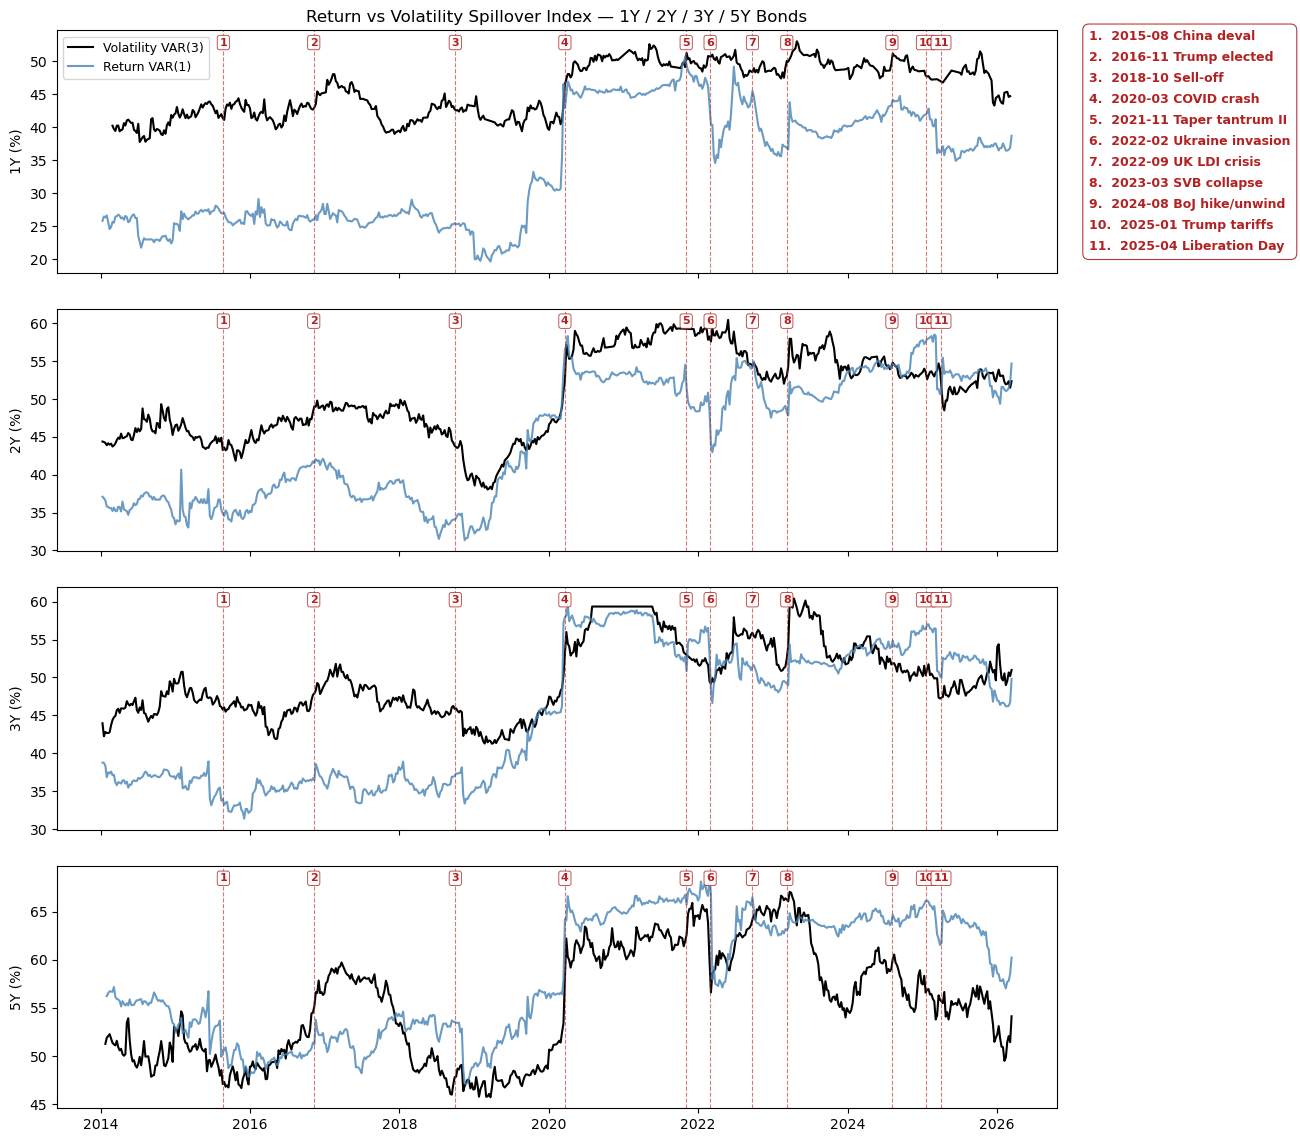

In [60]:
# ── DY 2008 FIGURE 1: Return vs Volatility Spillover — 1Y/2Y/3Y/5Y ────────────
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

ROLL_WINDOW   = 104
VAR_LAGS_RET  = 1    # returns: VAR(1)
VAR_LAGS_VOL  = 3    # volatility: AIC-selected from volatility_testing
FEVD_H        = 10
TERMS         = [1, 2, 3, 5]

events = {
    "2015-08 China deval":       "2015-08-24",
    "2016-11 Trump elected":     "2016-11-08",
    "2018-10 Sell-off":          "2018-10-01",
    "2020-03 COVID crash":       "2020-03-20",
    "2021-11 Taper tantrum II":  "2021-11-03",
    "2022-02 Ukraine invasion":  "2022-02-28",
    "2022-09 UK LDI crisis":     "2022-09-23",
    "2023-03 SVB collapse":      "2023-03-10",
    "2024-08 BoJ hike/unwind":   "2024-08-05",
    "2025-01 Trump tariffs":     "2025-01-20",
    "2025-04 Liberation Day":    "2025-04-02",
}

def rolling_spillover(input_df, var_lags):
    ts  = {}
    idx = input_df.index
    for i in range(ROLL_WINDOW, len(idx)):
        w = input_df.iloc[i - ROLL_WINDOW : i].replace([np.inf, -np.inf], np.nan).dropna()
        if len(w) < ROLL_WINDOW * 0.8:
            continue
        try:
            r = VAR(w).fit(var_lags)
            g, n = generalized_fevd(r, H=FEVD_H, normalize=True)
            _, tot = spillover_table(g, n)
            ts[idx[i]] = tot
        except Exception:
            continue
    return pd.Series(ts)

fig, axes = plt.subplots(len(TERMS), 1, figsize=(16, 14), sharex=True)
fig.subplots_adjust(right=0.75, hspace=0.15)

for ax, t in zip(axes, TERMS):
    ret_df = get_yield(term=t, freq='W-FRI').diff().dropna()
    raw_d  = get_yield(term=t, freq='B')
    chg_d  = raw_d.diff().dropna()
    rvol_w = (chg_d ** 2).resample('W-FRI').sum().apply(np.sqrt)
    vol_df = np.log(rvol_w.replace(0, np.nan)).dropna()

    s_ret = rolling_spillover(ret_df, VAR_LAGS_RET)
    s_vol = rolling_spillover(vol_df, VAR_LAGS_VOL)

    ax.plot(s_vol.index, s_vol.values, lw=1.5, color="black",     label=f"Volatility VAR({VAR_LAGS_VOL})")
    ax.plot(s_ret.index, s_ret.values, lw=1.5, color="steelblue", label=f"Return VAR({VAR_LAGS_RET})", alpha=0.8)

    trans = blended_transform_factory(ax.transData, ax.transAxes)
    common_start = max(s_ret.index.min(), s_vol.index.min())
    common_end   = max(s_ret.index.max(), s_vol.index.max())
    for i, (label, date) in enumerate(events.items(), 1):
        d = pd.to_datetime(date)
        if not (common_start <= d <= common_end):
            continue
        ax.axvline(d, color="firebrick", lw=0.8, ls="--", alpha=0.6)
        ax.text(d, 0.97, str(i), transform=trans,
                ha="center", va="top", fontsize=8, color="firebrick", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="firebrick", lw=0.6, alpha=0.9))

    ax.set_ylabel(f"{t}Y (%)", fontsize=10)
    if ax is axes[0]:
        ax.legend(loc="upper left", fontsize=9)

axes[0].set_title("Return vs Volatility Spillover Index — 1Y / 2Y / 3Y / 5Y Bonds")

legend_lines = [f"{i}.  {label}" for i, label in enumerate(events.keys(), 1)]
fig.text(0.77, 0.88, "\n".join(legend_lines), va="top", ha="left", fontsize=9,
         fontweight="bold", color="firebrick", linespacing=1.8,
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="firebrick", lw=0.8, alpha=0.9))

plt.show()
